In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Masks found: 200
Unique pixel values across 200 masks: [0, 1, 2, 3, 4, 5, 6, 7, 8, 247, 248, 249, 250, 251, 252, 253, 254, 255]
Blank masks (all-zero): 0/200  (0.0%)
brisc2025_test_00001_gl_ax_t1.png  →  unique: [  0   1   2   3   4   5   7 248 249 250 251 252 253 254 255]  max: 255
brisc2025_test_00004_gl_ax_t1.png  →  unique: [  0   1   2   3   4   5   6   7 249 250 251 252 253 254 255]  max: 255
brisc2025_test_00005_gl_ax_t1.png  →  unique: [  0   1   2   3   4   5   6 248 250 251 252 253 254 255]  max: 255
brisc2025_test_00006_gl_ax_t1.png  →  unique: [  0   1   2   3   4   5   6 248 249 250 251 252 253 254 255]  max: 255
brisc2025_test_00008_gl_ax_t1.png  →  unique: [  0   1   2   3   4   5   6   7 250 251 252 253 254 255]  max: 255


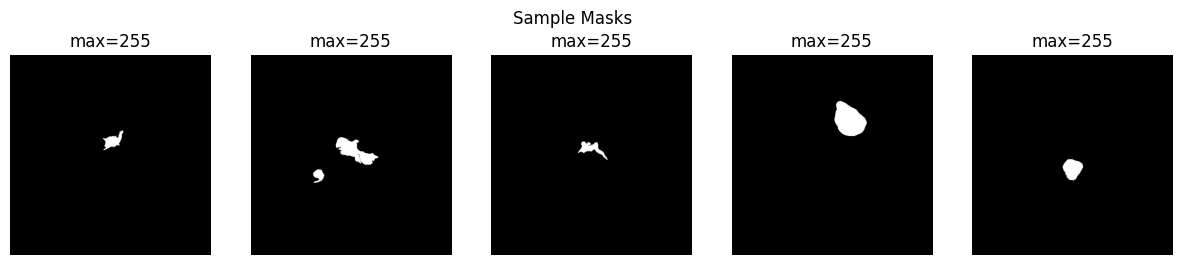

In [ ]:
# ***DIAGNOSTIC***

import cv2, numpy as np, matplotlib.pyplot as plt
from glob import glob

TRAIN_MASK = "/content/drive/MyDrive/Project work/Dataset/brisc2025/segmentation_task_ttv/train/masks"

mask_paths = sorted(glob(TRAIN_MASK + "/*"))[:200]
print("Masks found:", len(mask_paths))

unique_vals = set()
blank_count = 0

for p in mask_paths:
    m = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    if m is None:
        print("Still None:", p); break
    unique_vals.update(np.unique(m).tolist())
    if np.max(m) == 0:
        blank_count += 1

print("Unique pixel values across 200 masks:", sorted(unique_vals))
print(f"Blank masks (all-zero): {blank_count}/200  ({blank_count/2:.1f}%)")

for p in mask_paths[:5]:
    m = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    print(f"{p.split('/')[-1]}  →  unique: {np.unique(m)}  max: {m.max()}")

plt.figure(figsize=(15,3))
for i, p in enumerate(mask_paths[:5]):
    m = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    plt.subplot(1,5,i+1)
    plt.imshow(m, cmap="gray")
    plt.title(f"max={m.max()}")
    plt.axis("off")
plt.suptitle("Sample Masks")
plt.show()

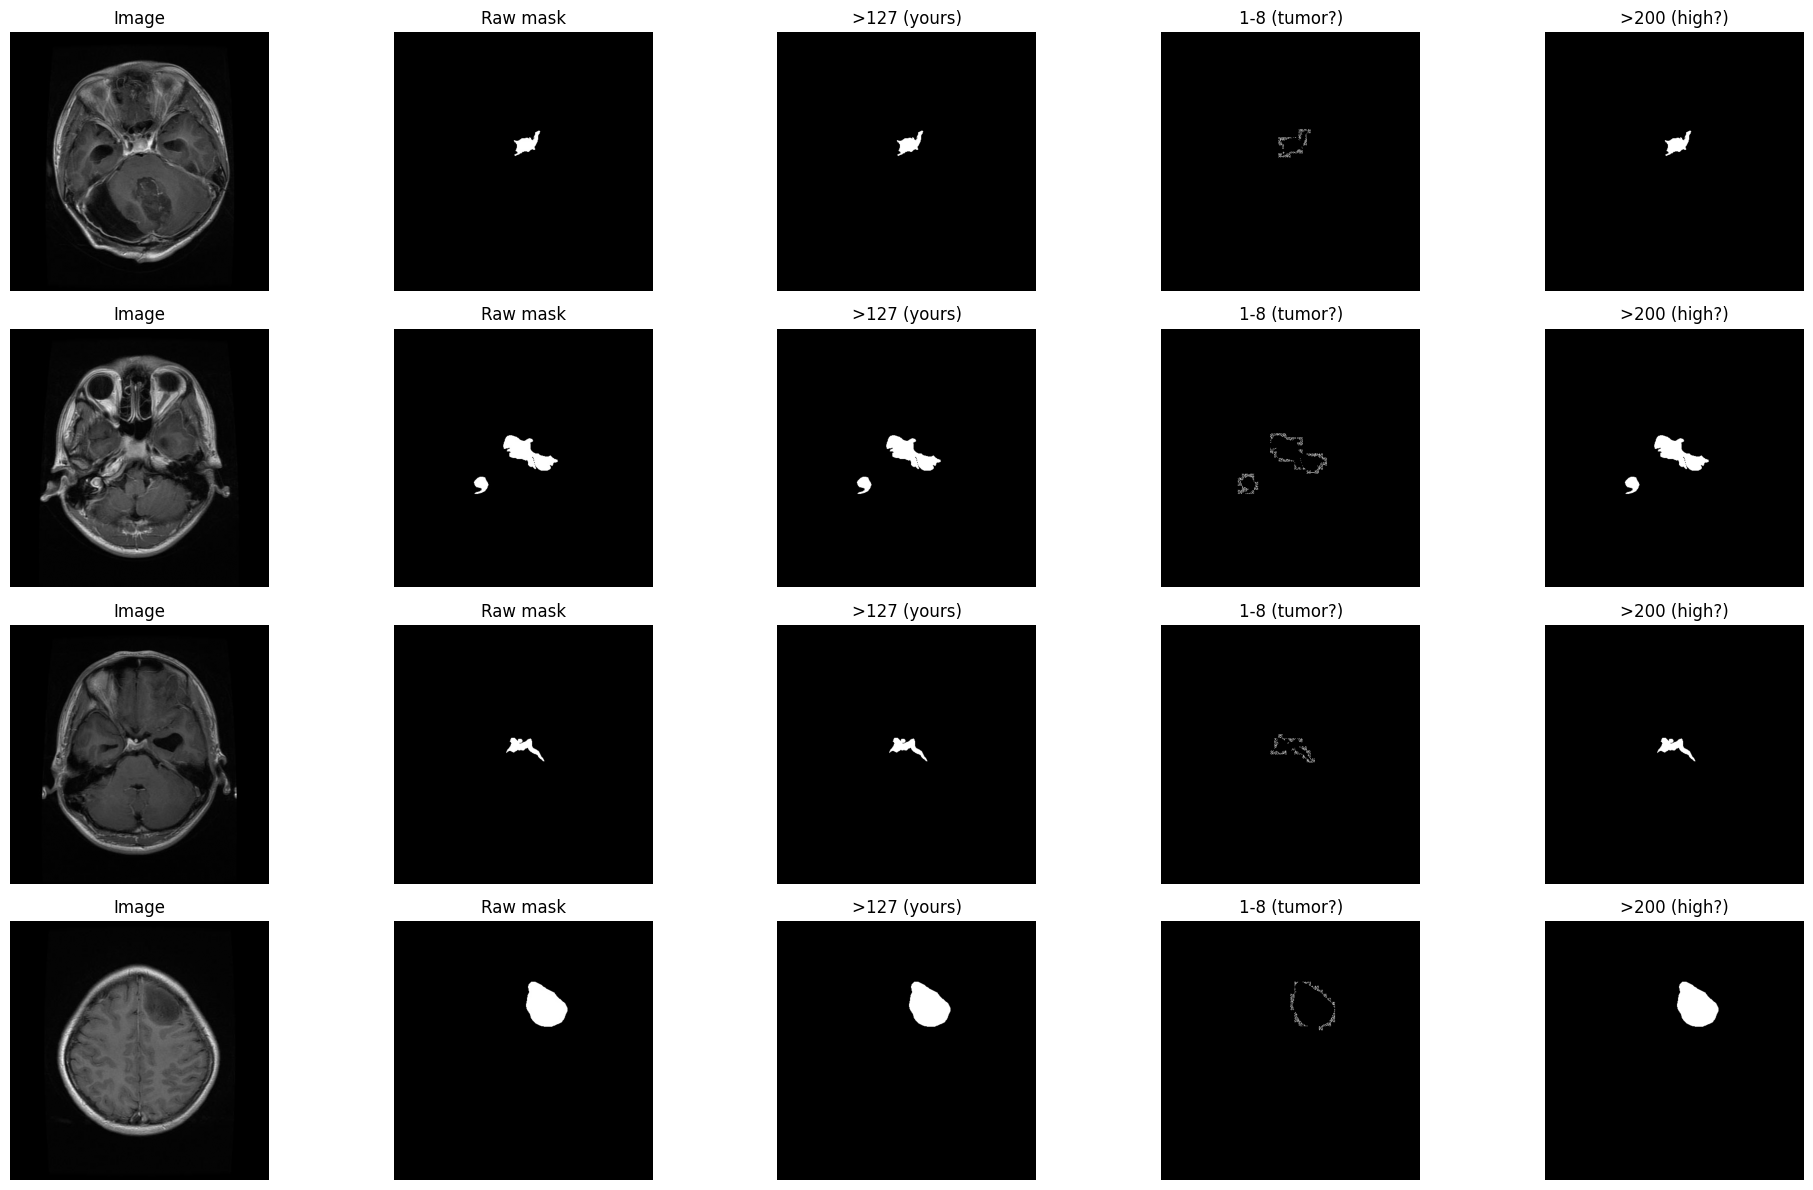

In [ ]:
# ***LABEL CHECK***

import cv2, numpy as np, matplotlib.pyplot as plt
from glob import glob

TRAIN_IMG  = "/content/drive/MyDrive/Project work/Dataset/brisc2025/segmentation_task_ttv/train/images"
TRAIN_MASK = "/content/drive/MyDrive/Project work/Dataset/brisc2025/segmentation_task_ttv/train/masks"

img_paths  = sorted(glob(TRAIN_IMG  + "/*"))
mask_paths = sorted(glob(TRAIN_MASK + "/*"))

# Show same image with 3 different binarizations side by side
plt.figure(figsize=(20, 12))
for i in range(4):
    img  = cv2.imread(img_paths[i],  cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(mask_paths[i], cv2.IMREAD_GRAYSCALE)

    bin_127  = (mask > 127).astype(np.uint8) * 255   # your current method
    bin_low  = ((mask >= 1) & (mask <= 8)).astype(np.uint8) * 255   # low labels only
    bin_high = (mask > 200).astype(np.uint8) * 255   # high values only

    plt.subplot(4,5,i*5+1); plt.imshow(img,      cmap="gray");  plt.title("Image");       plt.axis("off")
    plt.subplot(4,5,i*5+2); plt.imshow(mask,      cmap="gray");  plt.title("Raw mask");    plt.axis("off")
    plt.subplot(4,5,i*5+3); plt.imshow(bin_127,   cmap="gray");  plt.title(">127 (yours)");plt.axis("off")
    plt.subplot(4,5,i*5+4); plt.imshow(bin_low,   cmap="gray");  plt.title("1-8 (tumor?)");plt.axis("off")
    plt.subplot(4,5,i*5+5); plt.imshow(bin_high,  cmap="gray");  plt.title(">200 (high?)");plt.axis("off")

plt.tight_layout()
plt.show()

High-value label combos found across all train masks:
  values (np.uint8(248), np.uint8(249), np.uint8(250), np.uint8(251), np.uint8(252), np.uint8(253), np.uint8(254), np.uint8(255))  →  1748 images
  values (np.uint8(249), np.uint8(250), np.uint8(251), np.uint8(252), np.uint8(253), np.uint8(254), np.uint8(255))  →  1217 images
  values (np.uint8(250), np.uint8(251), np.uint8(252), np.uint8(253), np.uint8(254), np.uint8(255))  →  404 images
  values (np.uint8(248), np.uint8(250), np.uint8(251), np.uint8(252), np.uint8(253), np.uint8(254), np.uint8(255))  →  323 images
  values (np.uint8(247), np.uint8(248), np.uint8(249), np.uint8(250), np.uint8(251), np.uint8(252), np.uint8(253), np.uint8(254), np.uint8(255))  →  53 images
  values (np.uint8(247), np.uint8(249), np.uint8(250), np.uint8(251), np.uint8(252), np.uint8(253), np.uint8(254), np.uint8(255))  →  33 images
  values (np.uint8(247), np.uint8(248), np.uint8(250), np.uint8(251), np.uint8(252), np.uint8(253), np.uint8(254), np.uin

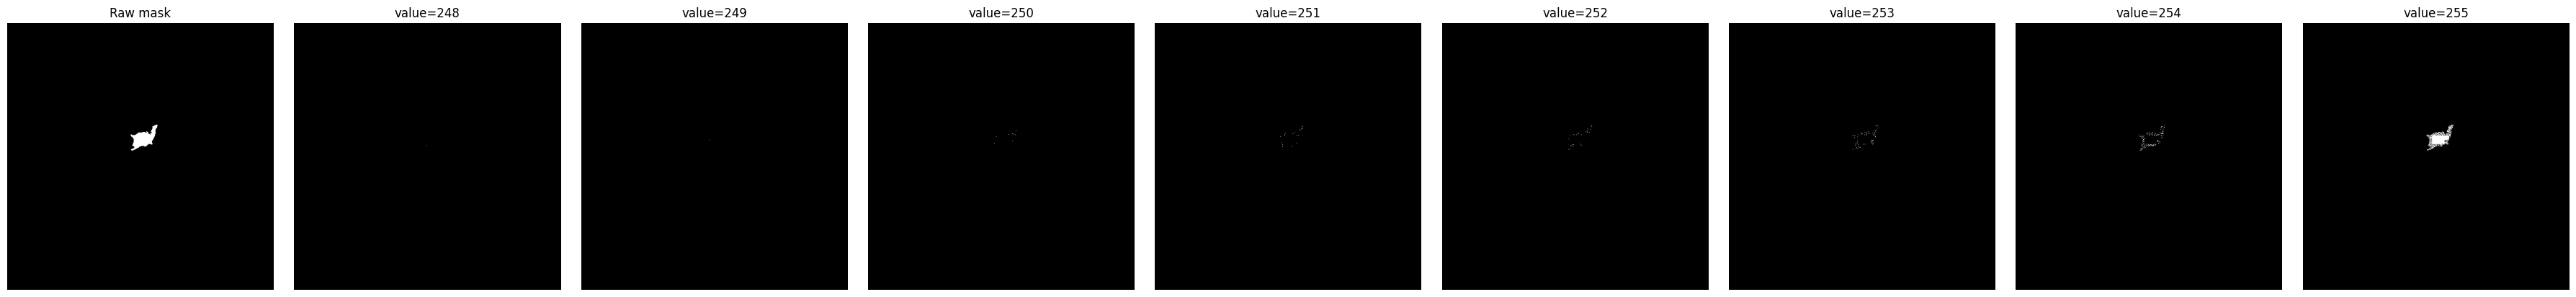

In [ ]:
# ***MASK LABEL ANALYSIS***

import cv2, numpy as np, matplotlib.pyplot as plt
from glob import glob
from collections import Counter

TRAIN_MASK = "/content/drive/MyDrive/Project work/Dataset/brisc2025/segmentation_task_ttv/train/masks"
mask_paths = sorted(glob(TRAIN_MASK + "/*"))

# Count how many unique high-value combos exist per image
combo_counter = Counter()
for p in mask_paths:
    m = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    high_vals = tuple(sorted([v for v in np.unique(m) if v > 200]))
    if high_vals:
        combo_counter[high_vals] += 1

print("High-value label combos found across all train masks:")
for combo, count in combo_counter.most_common(10):
    print(f"  values {combo}  →  {count} images")

# Visualize one image with each high value shown separately
sample = mask_paths[0]
m = cv2.imread(sample, cv2.IMREAD_GRAYSCALE)
high_vals = sorted([v for v in np.unique(m) if v > 200])

print(f"\nSample mask high values: {high_vals}")

n = len(high_vals) + 1
plt.figure(figsize=(4*n, 4))
plt.subplot(1, n, 1)
plt.imshow(m, cmap="gray")
plt.title("Raw mask")
plt.axis("off")

for i, v in enumerate(high_vals):
    layer = (m == v).astype(np.uint8) * 255
    plt.subplot(1, n, i+2)
    plt.imshow(layer, cmap="gray")
    plt.title(f"value={v}")
    plt.axis("off")

plt.tight_layout()
plt.show()